In [ ]:
# 1.Google Drive 연결 및 작업공간 설정
from google.colab import drive
import os

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/deeplearning_study')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2.Pkg's
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
# 3.Fashion MNIST loading
fashion_mnist = keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(60000, 28, 28) (10000, 28, 28) (60000,) (10000,)


In [ ]:
# 참고. 원본데이터 형태 : train은 2차원, test는 1차원 배열
np.set_printoptions(linewidth=200)
print(X_train[0])
print(y_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178 107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216 216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 232 233 229 223 22

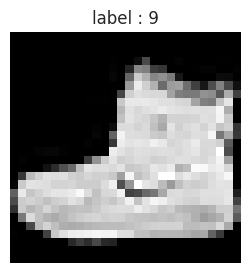

In [ ]:
# 첫번째 이미지
plt.figure(figsize=(3,3))
plt.imshow(X_train[0], cmap='gray')
plt.title(f"label : {y_train[0]}")
plt.axis('off')
plt.show()

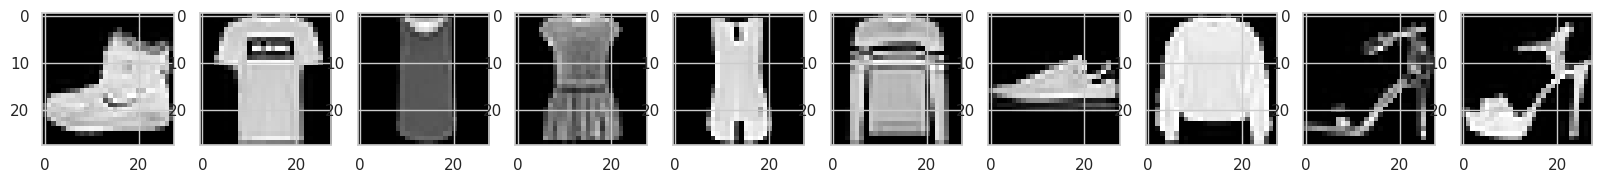

In [ ]:
fig, axes = plt.subplots(1, 10, figsize=(20, 2))

for i in range(10):
    axes[i].imshow(X_train[i], cmap='gray')
    #axes[i].axis('off')

plt.show()

---
#### 1. Logistic Regression
---

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 0~255 → 0~1 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

# (60000, 28, 28) → (60000, 784)
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# model & eval
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

lr_pred = model_lr.predict(X_test)
acc = accuracy_score(y_test, lr_pred)

print('Accuracy = ', acc)

Accuracy = ,  0.8439


---
#### 2. Neural Network
---

In [ ]:
# 패캐지
import tensorflow as tf
from tensorflow import keras
from keras import layers
tf.config.list_physical_devices('GPU')

# 데이터 로딩
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(60000, 28, 28) (10000, 28, 28) (60000,) (10000,)


In [ ]:
# 벡터화 : 28x28 --> 784개 특성으로 변환
# 정규화 : 0~255 --> 0~1 범위 변환
X_train = X_train.reshape(-1, 28*28) / 255.0
X_test = X_test.reshape(-1, 28*28) / 255.0
print(X_train.shape, X_test.shape)

(60000, 784) (10000, 784)


In [ ]:
# 신경망 정의
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(28*28,)),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 학습
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7675 - loss: 0.6626 - val_accuracy: 0.8514 - val_loss: 0.4159
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8567 - loss: 0.4005 - val_accuracy: 0.8660 - val_loss: 0.3727
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8764 - loss: 0.3428 - val_accuracy: 0.8675 - val_loss: 0.3659
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8812 - loss: 0.3237 - val_accuracy: 0.8600 - val_loss: 0.3989
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8906 - loss: 0.2980 - val_accuracy: 0.8765 - val_loss: 0.3439


In [ ]:
# history에는 5회의 반복훈련 결과가 기록되어 있다. (history는 dictionary 형태)
print(history.history)

df_history = pd.DataFrame(history.history)
df_history.head()

{'accuracy': [0.8198750019073486, 0.859250009059906, 0.8751875162124634, 0.883062481880188, 0.8894374966621399], 'loss': [0.5137964487075806, 0.38878539204597473, 0.3453468084335327, 0.32120686769485474, 0.30056092143058777], 'val_accuracy': [0.8514166474342346, 0.8659999966621399, 0.8675000071525574, 0.8600000143051147, 0.8765000104904175], 'val_loss': [0.41591617465019226, 0.37268170714378357, 0.3659181296825409, 0.39893773198127747, 0.34386295080184937]}


,accuracy,loss,val_accuracy,val_loss
0,0.819875,0.513796,0.851417,0.415916
1,0.859250,0.388785,0.866000,0.372682
2,0.875188,0.345347,0.867500,0.365918
3,0.883062,0.321207,0.860000,0.398938
4,0.889437,0.300561,0.876500,0.343863


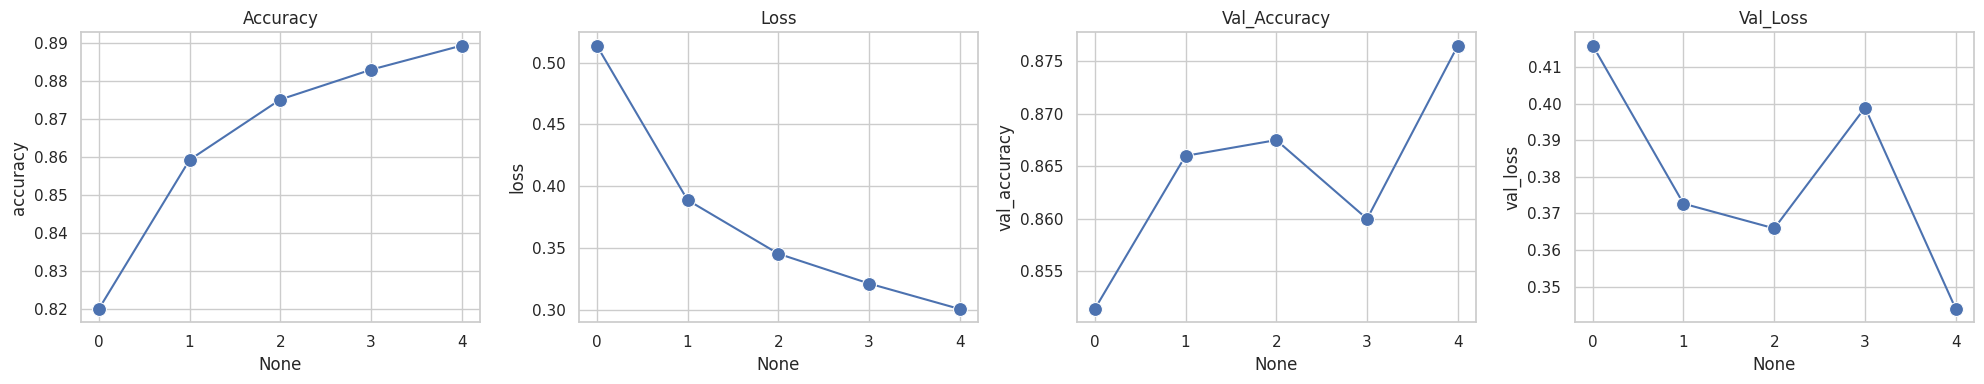

In [ ]:
# history 기록을 사용한 시각화
fig, axes = plt.subplots(1,4, figsize=(20,4))

sns.lineplot(data=df_history, x=df_history.index, y='accuracy', marker='o', ms=10, ax=axes[0])
sns.lineplot(data=df_history, x=df_history.index, y='loss', marker='o', ms=10, ax=axes[1])
sns.lineplot(data=df_history, x=df_history.index, y='val_accuracy', marker='o', ms=10, ax=axes[2])
sns.lineplot(data=df_history, x=df_history.index, y='val_loss', marker='o', ms=10, ax=axes[3])

axes[0].set_title('Accuracy')
axes[1].set_title('Loss')
axes[2].set_title('Val_Accuracy')
axes[3].set_title('Val_Loss')

plt.tight_layout()
plt.show()

In [ ]:
# 최종평가
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Accuracy =", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8672 - loss: 0.3693
Accuracy = 0.866100013256073


#### 3. Add layer

In [ ]:
# 기존모델에 레이어 1개 추가
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 학습
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# 최종평가
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Accuracy =", test_acc)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7660 - loss: 0.6597 - val_accuracy: 0.8502 - val_loss: 0.4094
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8587 - loss: 0.3868 - val_accuracy: 0.8658 - val_loss: 0.3717
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8749 - loss: 0.3416 - val_accuracy: 0.8701 - val_loss: 0.3580
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8817 - loss: 0.3141 - val_accuracy: 0.8776 - val_loss: 0.3465
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8876 - loss: 0.3013 - val_accuracy: 0.8793 - val_loss: 0.3360
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8707 - loss: 0.3699
Accuracy = 0.8716999888420105


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Accuracy =", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8707 - loss: 0.3699
Accuracy = 0.8716999888420105


#### 4. 성능 개선 : layers, epochs 증가

In [ ]:
# 성능개선을 위해 layer 개수와 epochs 증가

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 830,090 (3.17 MB)

 Trainable params: 830,090 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7629 - loss: 0.6495 - val_accuracy: 0.8248 - val_loss: 0.4768
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8557 - loss: 0.3951 - val_accuracy: 0.8643 - val_loss: 0.3889
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8762 - loss: 0.3416 - val_accuracy: 0.8717 - val_loss: 0.3682
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8819 - loss: 0.3199 - val_accuracy: 0.8431 - val_loss: 0.4416
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8886 - loss: 0.2972 - val_accuracy: 0.8693 - val_loss: 0.3555
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8951 - loss: 0.2826 - val_accuracy: 0.8742 - val_loss: 0.3462
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8999 - loss: 0.2695 - val_accuracy: 0.8720 - val_loss: 0.3518
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9059 - loss: 0.2526 - 

,accuracy,loss,val_accuracy,val_loss,epoch
0,0.814250,0.511485,0.824750,0.476791,1
1,0.859708,0.383719,0.864333,0.388945,2
2,0.873812,0.343759,0.871667,0.368153,3
3,0.882521,0.319208,0.843083,0.441551,4
4,0.889813,0.297644,0.869333,0.355456,5


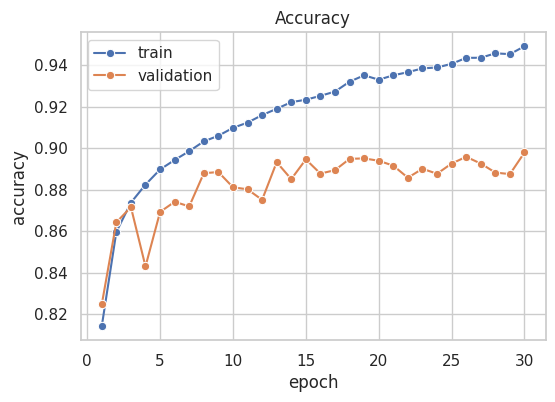

In [ ]:
# 학습결과 확인
df_history = pd.DataFrame(history.history)
df_history['epoch'] = df_history.index + 1
display(df_history.head())

plt.figure(figsize=(6,4))
sns.lineplot(data=df_history, x='epoch', y='accuracy', marker='o', ms=6, label='train')
sns.lineplot(data=df_history, x='epoch', y='val_accuracy', marker='o', ms=6, label='validation')

plt.title('Accuracy')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Accuracy =", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8868 - loss: 0.5375
Accuracy = 0.88919997215271


#### 5. 모델 일반화 : Drop Out

In [ ]:
# Overfitting 방지 위해 drop out = 0.3 적용
model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 830,090 (3.17 MB)

 Trainable params: 830,090 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7087 - loss: 0.7812 - val_accuracy: 0.8412 - val_loss: 0.4298
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8325 - loss: 0.4655 - val_accuracy: 0.8519 - val_loss: 0.4106
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8445 - loss: 0.4246 - val_accuracy: 0.8671 - val_loss: 0.3679
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8564 - loss: 0.4035 - val_accuracy: 0.8685 - val_loss: 0.3658
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8619 - loss: 0.3820 - val_accuracy: 0.8720 - val_loss: 0.3552
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8657 - loss: 0.3699 - val_accuracy: 0.8773 - val_loss: 0.3405
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8677 - loss: 0.3613 - val_accuracy: 0.8731 - val_loss: 0.3574
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8706 - loss: 0.3581 -

,accuracy,loss,val_accuracy,val_loss,epoch
0,0.776937,0.607585,0.841167,0.429843,1
1,0.833938,0.459869,0.851917,0.410552,2
2,0.845125,0.425623,0.867083,0.367930,3
3,0.856479,0.400887,0.868500,0.365770,4
4,0.860937,0.385139,0.872000,0.355238,5


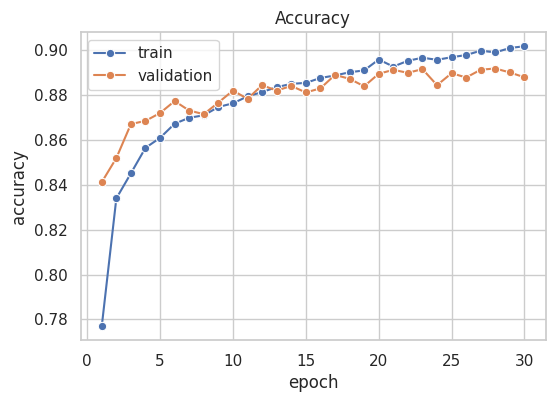

In [ ]:
# 학습결과 확인
df_history = pd.DataFrame(history.history)
df_history['epoch'] = df_history.index + 1
display(df_history.head())

plt.figure(figsize=(6,4))
sns.lineplot(data=df_history, x='epoch', y='accuracy', marker='o', ms=6, label='train')
sns.lineplot(data=df_history, x='epoch', y='val_accuracy', marker='o', ms=6, label='validation')

plt.title('Accuracy')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Accuracy =", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8779 - loss: 0.3563
Accuracy = 0.8794000148773193


---
#### 참고. 훈련된 모델의 저장

In [ ]:
# model save
model.save('f_minst_model.keras')  ## model.save('f_minst_model.h5')도 가능

# loading saved model
new_model = keras.models.load_model('f_minst_model.keras')
new_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,490,272 (9.50 MB)

 Trainable params: 830,090 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,660,182 (6.33 MB)